In [41]:
# Preprocessing Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Model Libraries
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error


from sklearn.linear_model import LinearRegression,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

import os
import joblib

In [42]:
df=pd.read_csv("../data/crop_yield.csv")
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [43]:
print(df.columns)
print(df.shape)

Index(['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius',
       'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition',
       'Days_to_Harvest', 'Yield_tons_per_hectare'],
      dtype='str')
(1000000, 10)


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  str    
 1   Soil_Type               1000000 non-null  str    
 2   Crop                    1000000 non-null  str    
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  str    
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 82.0 MB


In [45]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [46]:
df["Region"].unique()

<ArrowStringArray>
['West', 'South', 'North', 'East']
Length: 4, dtype: str

In [47]:
df["Soil_Type"].unique()

<ArrowStringArray>
['Sandy', 'Clay', 'Loam', 'Silt', 'Peaty', 'Chalky']
Length: 6, dtype: str

In [48]:
df["Crop"].unique()

<ArrowStringArray>
['Cotton', 'Rice', 'Barley', 'Soybean', 'Wheat', 'Maize']
Length: 6, dtype: str

In [49]:
df["Weather_Condition"].unique()

<ArrowStringArray>
['Cloudy', 'Rainy', 'Sunny']
Length: 3, dtype: str

In [50]:
df.isnull().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

<Axes: ylabel='Yield_tons_per_hectare'>

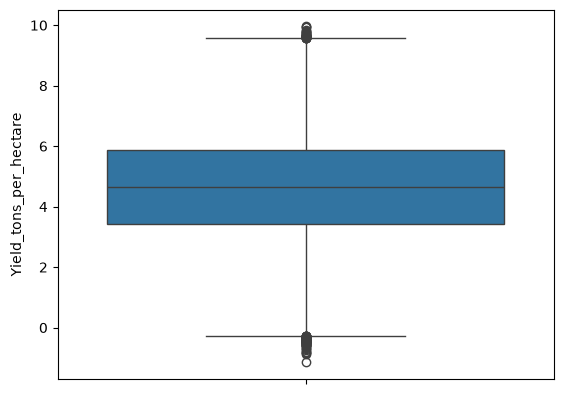

In [51]:
sns.boxplot(df['Yield_tons_per_hectare'])

In [52]:
# pivot = df.groupby(['Region', 'Soil_Type']).size().unstack()
# print(pivot)
# sns.heatmap(pivot, annot=True, cmap='coolwarm')
# plt.show()

In [53]:
corr_matrix1 = np.corrcoef(df["Irrigation_Used"], df["Yield_tons_per_hectare"])
corr_matrix1

array([[1.       , 0.3537409],
       [0.3537409, 1.       ]])

In [54]:
corr_matrix2 = np.corrcoef(df["Fertilizer_Used"], df["Yield_tons_per_hectare"])
corr_matrix2

array([[1.        , 0.44209932],
       [0.44209932, 1.        ]])

In [55]:
corr_matrix3 = np.corrcoef(df["Temperature_Celsius"], df["Yield_tons_per_hectare"])
corr_matrix3

array([[1.        , 0.08556513],
       [0.08556513, 1.        ]])

In [56]:
corr_matrix4 = np.corrcoef(df["Rainfall_mm"], df["Yield_tons_per_hectare"])
corr_matrix4

array([[1.        , 0.76461796],
       [0.76461796, 1.        ]])

In [57]:
# sns.heatmap(corr_matrix1, annot=True)

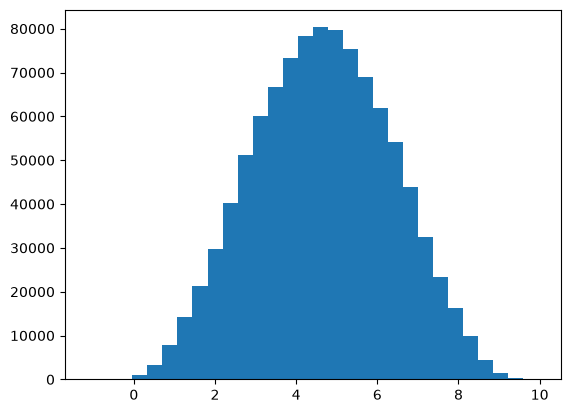

In [58]:
# region x yield
plt.hist(df["Yield_tons_per_hectare"],bins=30)
plt.show()

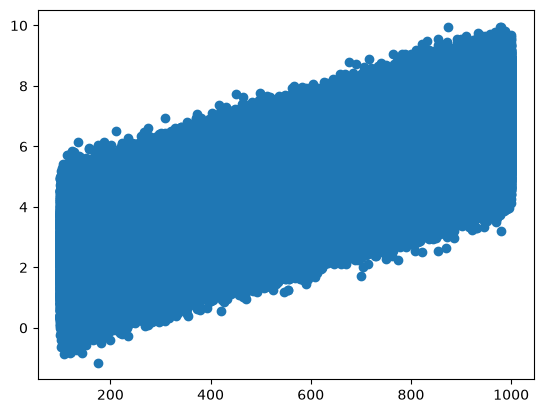

In [59]:
plt.scatter(df["Rainfall_mm"],df["Yield_tons_per_hectare"])
plt.show()

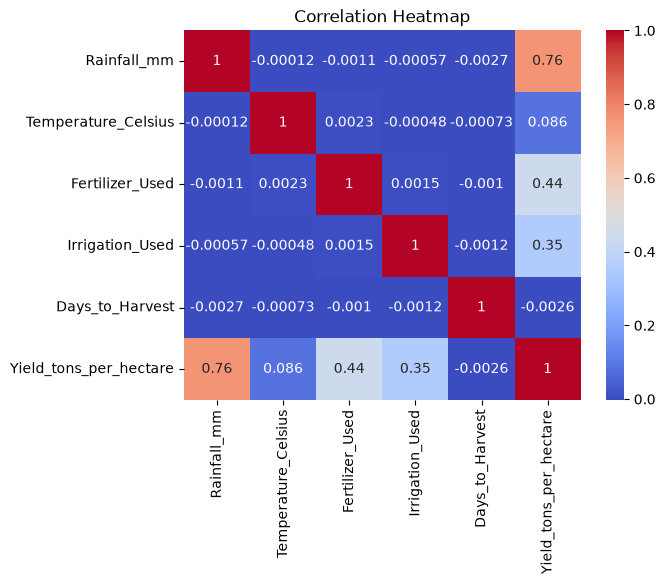

In [60]:
corr = df.corr(numeric_only=True)
# print(corr)
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

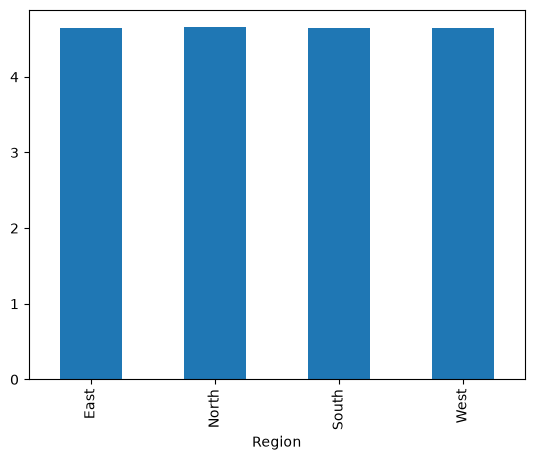

In [61]:
region_yield = df.groupby('Region')['Yield_tons_per_hectare'].mean()
region_yield.plot(kind="bar")
plt.show()

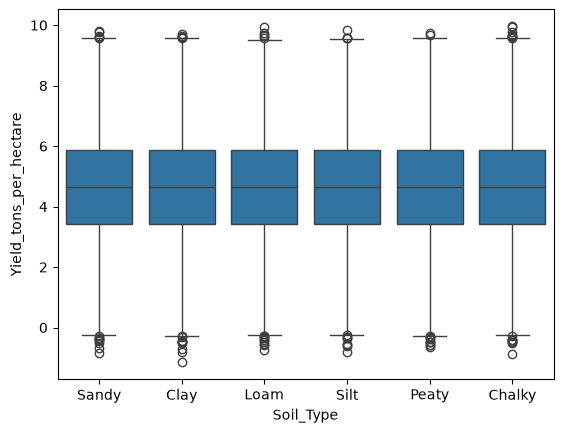

In [62]:
sns.boxplot(x=df["Soil_Type"],y=df["Yield_tons_per_hectare"])
plt.show()

<Axes: xlabel='Fertilizer_Used'>

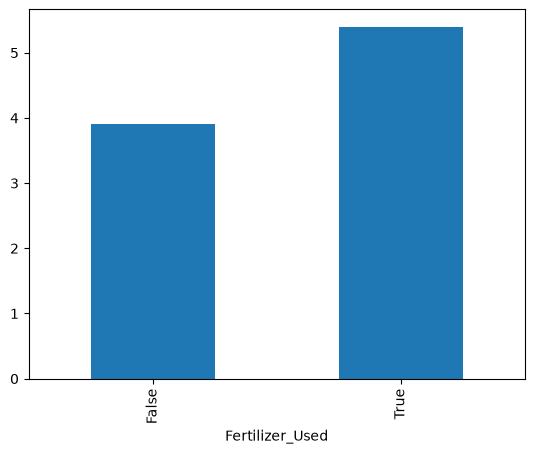

In [63]:
fert=df.groupby("Fertilizer_Used")["Yield_tons_per_hectare"].mean()
fert.plot(kind="bar")

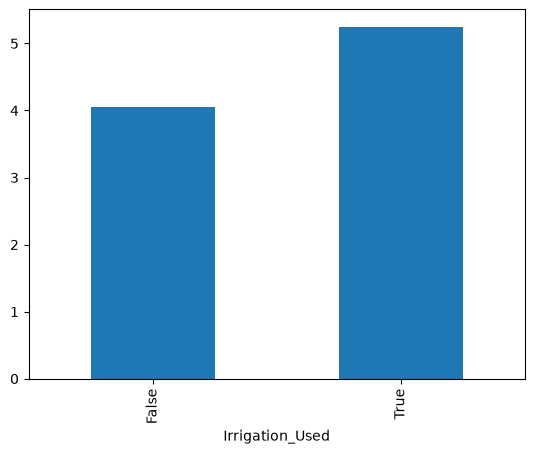

In [64]:
irri=df.groupby("Irrigation_Used")["Yield_tons_per_hectare"].mean()
irri.plot(kind="bar")
plt.show()

In [65]:
print(df.groupby("Region")["Yield_tons_per_hectare"].mean().sort_values(ascending=True))

Region
East     4.645594
South    4.648843
West     4.649331
North    4.654114
Name: Yield_tons_per_hectare, dtype: float64


In [66]:
print(df.groupby("Soil_Type")["Yield_tons_per_hectare"].mean().sort_values(ascending=True))

Soil_Type
Clay      4.644891
Silt      4.648414
Sandy     4.648511
Loam      4.651056
Peaty     4.651063
Chalky    4.652895
Name: Yield_tons_per_hectare, dtype: float64


In [67]:
# df["Rainfall_Category"] = pd.cut(
#     df["Rainfall_mm"],
#     bins=[0, 50, 100, 200],
#     labels=['Low', 'Medium', 'High']
# )
# df["Rainfall_Category"].unique()
# df

In [68]:
# pivot = df.pivot_table(
#     values='Yield_tons_per_hectare',
#     index='Rainfall_Category',
#     columns='Irrigation_Used',
#     aggfunc='mean'
# )

# print(pivot)

In [69]:
# Correct encoding: one-hot encode each categorical column so the model sees the same feature set every time
encoded_df = pd.get_dummies(
    df,
    columns=['Region', 'Soil_Type', 'Crop', 'Weather_Condition'],
    drop_first=False
)

new_df = encoded_df.copy()
new_df

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Region_East,Region_North,Region_South,Region_West,...,Soil_Type_Silt,Crop_Barley,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny
0,897.077239,27.676966,False,True,122,6.555816,False,False,False,True,...,False,False,True,False,False,False,False,True,False,False
1,992.673282,18.026142,True,True,140,8.527341,False,False,True,False,...,False,False,False,False,True,False,False,False,True,False
2,147.998025,29.794042,False,False,106,1.127443,False,True,False,False,...,False,True,False,False,False,False,False,False,False,True
3,986.866331,16.644190,False,True,146,6.517573,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
4,730.379174,31.620687,True,True,110,7.248251,False,False,True,False,...,True,False,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,302.805345,27.987428,False,False,76,1.347586,False,False,False,True,...,True,False,False,False,True,False,False,False,False,True
999996,932.991383,39.661039,True,False,93,7.311594,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
999997,867.362046,24.370042,True,False,108,5.763182,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False
999998,492.812857,33.045505,False,False,102,2.070159,False,False,False,True,...,True,False,False,False,False,False,True,False,False,True


In [70]:
# df_encoded=pd.get_dummies(df,drop_first=True)
# df_encoded

In [71]:
x0=new_df.drop("Yield_tons_per_hectare",axis=1)
y0=new_df["Yield_tons_per_hectare"]
xtrain,xtest,ytrain,ytest=train_test_split(x0,y0,test_size=0.2,random_state=42)

In [72]:
linear_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear_pipe.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['Rainfall_mm','Temperature_Celsius','Fertilizer_Used',..., 'Weather_Condition_Cloudy','Weather_Condition_Rainy', 'Weather_Condition_Sunny']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [73]:
from sklearn.metrics import r2_score

y_pred = linear_pipe.predict(xtest)

print("R2 Score:", r2_score(ytest, y_pred))


R2 Score: 0.9130137709140373


In [74]:
models = {
    "linear": LinearRegression(),
    "ridge": Ridge(),
    "decision_tree": DecisionTreeRegressor(),
    "random_forest": RandomForestRegressor(),
    "gradient_boosting": GradientBoostingRegressor(),
    "knn": KNeighborsRegressor(),
    "xgboost": XGBRegressor()
}
for name, model in models.items():
    file_name = f"../models/{name}.pkl"
    
    # Check if model already exists
    if os.path.exists(file_name):
        print(f"{name} already exists → Loading...")
        model = joblib.load(file_name)
        
    else:
        print(f"Training {name}...")
        model.fit(xtrain, ytrain)
        joblib.dump(model, file_name)
        print(f"{name} saved!")

linear already exists → Loading...
ridge already exists → Loading...
decision_tree already exists → Loading...
random_forest already exists → Loading...
gradient_boosting already exists → Loading...
knn already exists → Loading...
Training xgboost...
xgboost saved!


In [75]:
results = []
for name in models.keys():
    
    model = joblib.load(f"{name}.pkl")

    # Predict
    y_pred = model.predict(xtest)
    
    # Metrics
    r2 = r2_score(ytest, y_pred)
    mae = mean_absolute_error(ytest, y_pred)
    
    # Store results
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae
    })

print(results)

python(20696) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[{'Model': 'linear', 'R2 Score': 0.9130137709140373, 'MAE': 0.39955408087134897}, {'Model': 'ridge', 'R2 Score': 0.9130137620997583, 'MAE': 0.39955410561321014}, {'Model': 'decision_tree', 'R2 Score': 0.8151724782365779, 'MAE': 0.5834661824153965}, {'Model': 'random_forest', 'R2 Score': 0.9076921228855506, 'MAE': 0.4114965922793049}, {'Model': 'gradient_boosting', 'R2 Score': 0.9124540871255222, 'MAE': 0.400855954160647}, {'Model': 'knn', 'R2 Score': 0.6566132629762218, 'MAE': 0.8043359054894792}, {'Model': 'xgboost', 'R2 Score': 0.9123938534051498, 'MAE': 0.4009519052490416}]


In [41]:
results_df = pd.DataFrame(results)

# Sort by best model
results_df = results_df.sort_values(by="R2 Score", ascending=False)
results_df.to_csv("../models/model_comparison.csv")
print("\nModel Comparison:\n")
print(results_df)


Model Comparison:

               Model  R2 Score       MAE
0             linear  0.913015  0.399552
1              ridge  0.913015  0.399552
4  gradient_boosting  0.912454  0.400855
3      random_forest  0.907339  0.412416
2      decision_tree  0.815320  0.582821
5                knn  0.596953  0.874673
